# CIC-IDS2017 Network Intrusion Detection: Data Preprocessing

This notebook handles the initial data ingestion, merging of daily traffic captures, and comprehensive cleaning of the CIC-IDS2017 dataset.

### 1. Environment Setup
Mounting Google Drive and setting up directory paths for raw and processed data.

In [ ]:
# Consolidated imports
from google.colab import drive
import os
import glob
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# mounting drive to access files
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE_PATH = "/content/drive/MyDrive/Network Intrusion Detection"
RAW_PATH = os.path.join(BASE_PATH, "raw_data")
MERGED_PATH = os.path.join(BASE_PATH, "merged")

os.makedirs(MERGED_PATH, exist_ok=True)

print("Files in raw_data:")
print(os.listdir(RAW_PATH))

Files in raw_data:
['Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'Friday-WorkingHours-Morning.pcap_ISCX.csv', 'Monday-WorkingHours.pcap_ISCX.csv', 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', 'Tuesday-WorkingHours.pcap_ISCX.csv', 'Wednesday-workingHours.pcap_ISCX.csv']


### 2. Exploratory Data Inspection
Before merging, we inspect the individual CSV files to understand their scale and ensure consistent column counts.

In [ ]:
files = glob.glob(os.path.join(RAW_PATH, "*.csv"))

# Order days manually
day_order = {
    "Monday": 1,
    "Tuesday": 2,
    "Wednesday": 3,
    "Thursday": 4,
    "Friday": 5
}

data_summary = []

for f in files:
    filename = os.path.basename(f)

    # detect day from filename
    day_rank = 99
    for day, rank in day_order.items():
        if day in filename:
            day_rank = rank
            break

    # read minimal rows just to get shape
    df = pd.read_csv(f, low_memory=False)
    rows, cols = df.shape

    data_summary.append({
        "File": filename,
        "Rows": rows,
        "Columns": cols,
        "DayOrder": day_rank
    })

# Convert to DataFrame
summary_df = pd.DataFrame(data_summary)

# Sort by day of week
summary_df = summary_df.sort_values("DayOrder").drop(columns=["DayOrder"])

# Display nicely
print(summary_df.to_string(index=False))

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_49889/3384304290.py", line 25, in <cell line: 0>
    df = pd.read_csv(f, low_memory=False)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 1026, in read_csv
    return _read(filepath_or_buffer, kwds)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 626, in _read
    return parser.read(nrows)
           ^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 1923, in read
    ) = self._engine.read(  # type: ignore[attr-defined]
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/c_parser_wrapper.py", lin

TypeError: object of type 'NoneType' has no len()

In [ ]:
files = sorted(glob.glob(os.path.join(RAW_PATH, "*.csv")))

summary = []

for f in files:
    df = pd.read_csv(f, low_memory=False)
    rows, cols = df.shape
    summary.append((os.path.basename(f), rows, cols))

for name, rows, cols in summary:
    print(f"{name}: {rows} rows, {cols} columns")

expected_total = sum(rows for _, rows, _ in summary)
print("\nExpected total rows:", expected_total)

Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: 225745 rows, 79 columns
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv: 286467 rows, 79 columns
Friday-WorkingHours-Morning.pcap_ISCX.csv: 191033 rows, 79 columns
Monday-WorkingHours.pcap_ISCX.csv: 529918 rows, 79 columns
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv: 288602 rows, 79 columns
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv: 170366 rows, 79 columns
Tuesday-WorkingHours.pcap_ISCX.csv: 445909 rows, 79 columns
Wednesday-workingHours.pcap_ISCX.csv: 692703 rows, 79 columns

Expected total rows: 2830743


### 3. Data Merging
Combining all daily PCAP-converted CSV files into a single unified dataset for analysis.

In [ ]:
os.makedirs(MERGED_PATH, exist_ok=True)
print("MERGED_PATH exists now:", os.path.exists(MERGED_PATH))

NameError: name 'MERGED_PATH' is not defined

In [ ]:
files = sorted(glob.glob(os.path.join(RAW_PATH, "*.csv")))
dfs = []

for f in files:
    print(f"Reading {os.path.basename(f)}...")
    df = pd.read_csv(f, low_memory=False)
    df.columns = df.columns.str.strip()
    print("Shape:", df.shape)
    dfs.append(df)

data = pd.concat(dfs, axis=0, ignore_index=True)

print("\nMerged shape:", data.shape)

Reading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...
Shape: (225745, 79)
Reading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
Shape: (286467, 79)
Reading Friday-WorkingHours-Morning.pcap_ISCX.csv...
Shape: (191033, 79)
Reading Monday-WorkingHours.pcap_ISCX.csv...
Shape: (529918, 79)
Reading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv...
Shape: (288602, 79)
Reading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv...
Shape: (170366, 79)
Reading Tuesday-WorkingHours.pcap_ISCX.csv...
Shape: (445909, 79)
Reading Wednesday-workingHours.pcap_ISCX.csv...
Shape: (692703, 79)

Merged shape: (2830743, 79)


In [ ]:
data.shape

(2830743, 79)

In [ ]:
os.makedirs(MERGED_PATH, exist_ok=True)

merged_file = os.path.join(MERGED_PATH, "CICIDS2017_merged.csv")
data.to_csv(merged_file, index=False)

print("Saved to:", merged_file)
print("File exists:", os.path.exists(merged_file))

NameError: name 'data' is not defined

### 4. Verification and Data Profiling
Checking the distribution of classes and identifying data quality issues such as duplicates, nulls, and infinite values.

In [ ]:
# Check if 'data' DataFrame already exists in the current session
if 'data' not in globals():
    merged_file = os.path.join(MERGED_PATH, "CICIDS2017_merged.csv")
    if os.path.exists(merged_file):
        print("Merged file found. Loading data from disk...")
        data = pd.read_csv(merged_file, low_memory=False)
        print("Merged rows:", data.shape[0])
        print("Merged columns:", data.shape[1])
    else:
        print("Merged file not found. Please run the data merging cells first (from 'Merging files together' section) to create 'data' DataFrame and save the merged file.")
        data = None # Assign None to 'data' to clearly indicate it's not loaded
else:
    print("DataFrame 'data' already exists in memory. Skipping file load.")
    print("Current 'data' rows:", data.shape[0])
    print("Current 'data' columns:", data.shape[1])

Merged file found. Loading data from disk...
Merged rows: 2830743
Merged columns: 79


In [ ]:
data.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
data.sample(10, random_state=42)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
746827,50545,232,1,1,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
946912,53,31226,2,2,68,380,34,34,34.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2216843,80,99951883,9,7,317,11595,317,0,35.222222,105.666667,...,32,999.0,0.0,999,999,99900000.0,0.0,99900000,99900000,DoS Hulk
699389,53,30894,4,2,140,172,35,35,35.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1170268,53,48943,2,2,88,166,44,44,44.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
800686,53,23728,1,1,56,84,56,56,56.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1434488,23,3,2,0,4,0,2,2,2.000000,0.000000,...,24,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1968368,80,141,2,0,0,0,0,0,0.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
934343,443,229,2,0,12,0,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
693547,443,176084,10,8,559,5437,192,0,55.900000,78.196974,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 int64  
 19  

In [ ]:
label_counts = data['Label'].value_counts()
label_percent = data['Label'].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    "Count": label_counts,
    "Percent": label_percent
})

summary

,Count,Percent
Label,,
BENIGN,2273097,80.300366
DoS Hulk,231073,8.162981
PortScan,158930,5.614427
DDoS,128027,4.522735
DoS GoldenEye,10293,0.363615
FTP-Patator,7938,0.280421
SSH-Patator,5897,0.208320
DoS slowloris,5796,0.204752
DoS Slowhttptest,5499,0.194260


In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Destination Port,2830743.0,8.071483e+03,1.828363e+04,0.0,53.0,80.0,443.0,65535.0
Flow Duration,2830743.0,1.478566e+07,3.365374e+07,-13.0,155.0,31316.0,3204828.5,119999998.0
Total Fwd Packets,2830743.0,9.361160e+00,7.496728e+02,1.0,2.0,2.0,5.0,219759.0
Total Backward Packets,2830743.0,1.039377e+01,9.973883e+02,0.0,1.0,2.0,4.0,291922.0
Total Length of Fwd Packets,2830743.0,5.493024e+02,9.993589e+03,0.0,12.0,62.0,187.0,12900000.0
...,...,...,...,...,...,...,...,...
Active Min,2830743.0,5.829582e+04,5.770923e+05,0.0,0.0,0.0,0.0,110000000.0
Idle Mean,2830743.0,8.316037e+06,2.363008e+07,0.0,0.0,0.0,0.0,120000000.0
Idle Std,2830743.0,5.038439e+05,4.602984e+06,0.0,0.0,0.0,0.0,76900000.0
Idle Max,2830743.0,8.695752e+06,2.436689e+07,0.0,0.0,0.0,0.0,120000000.0


In [ ]:
nunique = data.nunique().sort_values()
print("\nLowest unique value counts:")
print(nunique.head(10))


Lowest unique value counts:
Bwd PSH Flags           1
Fwd Avg Bulk Rate       1
Bwd Avg Bytes/Bulk      1
Bwd Avg Packets/Bulk    1
Fwd Avg Packets/Bulk    1
Fwd Avg Bytes/Bulk      1
Bwd Avg Bulk Rate       1
Bwd URG Flags           1
Fwd URG Flags           2
Fwd PSH Flags           2
dtype: int64


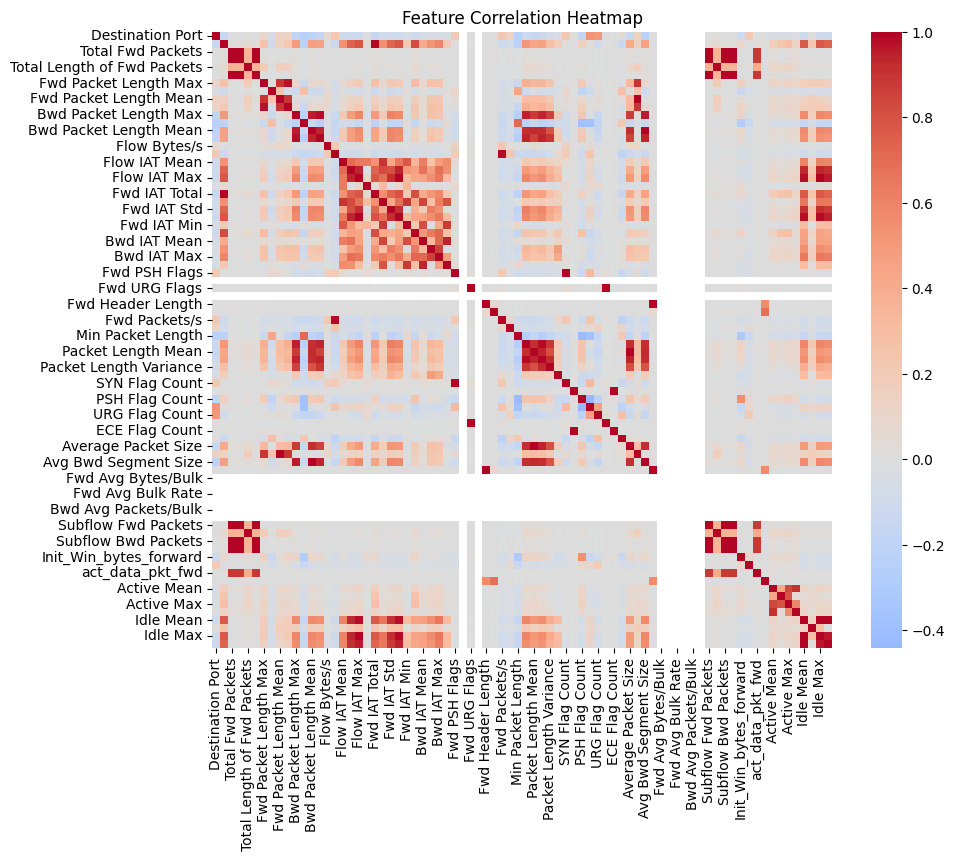

In [ ]:
corr = data.select_dtypes(include=['float64','int64']).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
print("Duplicate rows:", data.duplicated().sum())

Duplicate rows: 308381


In [ ]:
print("Null data:", data.isnull().sum().sum())

Null data: 1358


In [ ]:
print("Infinite values:", np.isinf(data.select_dtypes(include=np.number)).sum().sum())

Infinite values: 4376


In [ ]:
label_counts = data['Label'].value_counts()
print(label_counts)
print(f"Total unique classes: {len(label_counts)}")

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64
Total unique classes: 15


In [ ]:
data.select_dtypes(include=np.number).corr()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
Destination Port,1.000000,-0.151680,-0.004236,-0.003947,0.011145,-0.003082,0.097926,-0.045388,0.140220,0.128861,...,-0.003226,0.000897,-0.035562,-0.043717,-0.051859,-0.023194,-0.112585,0.010399,-0.108185,-0.114614
Flow Duration,-0.151680,1.000000,0.020857,0.019670,0.065456,0.016186,0.273308,-0.105230,0.143689,0.234437,...,0.015942,-0.001357,0.189299,0.241060,0.294034,0.121171,0.768034,0.243154,0.779527,0.738328
Total Fwd Packets,-0.004236,0.020857,1.000000,0.999070,0.365508,0.996993,0.009358,-0.002989,0.000032,0.001403,...,0.887387,-0.000184,0.039937,0.008329,0.030459,0.041283,0.001820,0.000809,0.001906,0.001670
Total Backward Packets,-0.003947,0.019670,0.999070,1.000000,0.359451,0.994429,0.009039,-0.002600,-0.000333,0.001026,...,0.882566,0.000018,0.038963,0.006437,0.028602,0.041278,0.001425,0.000492,0.001456,0.001330
Total Length of Fwd Packets,0.011145,0.065456,0.365508,0.359451,1.000000,0.353762,0.197030,-0.000275,0.185262,0.159787,...,0.407448,-0.001209,0.101084,0.103326,0.126493,0.068325,0.022660,0.027064,0.026079,0.018634
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Active Min,-0.023194,0.121171,0.041283,0.041278,0.068325,0.039069,0.105641,-0.025912,0.081170,0.094164,...,0.031394,-0.006834,0.905862,0.033874,0.584503,1.000000,0.118133,0.038302,0.122651,0.112880
Idle Mean,-0.112585,0.768034,0.001820,0.001425,0.022660,0.000809,0.181135,-0.071304,0.127959,0.183139,...,0.000837,-0.000876,0.120171,0.036551,0.088904,0.118133,1.000000,0.150248,0.990387,0.990215
Idle Std,0.010399,0.243154,0.000809,0.000492,0.027064,0.000105,0.178091,-0.029951,0.178462,0.191278,...,0.000721,-0.003720,0.070586,0.081435,0.070002,0.038302,0.150248,1.000000,0.283330,0.011609
Idle Max,-0.108185,0.779527,0.001906,0.001456,0.026079,0.000797,0.199559,-0.073419,0.148402,0.203304,...,0.000929,-0.001407,0.132700,0.055300,0.102816,0.122651,0.990387,0.283330,1.000000,0.961812


In [ ]:
data.select_dtypes(include=np.number).skew()

/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1256: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean


,0
Destination Port,2.072052
Flow Duration,2.155356
Total Fwd Packets,244.380553
Total Backward Packets,244.679507
Total Length of Fwd Packets,805.570539
...,...
Active Min,47.684006
Idle Mean,3.065489
Idle Std,10.493404
Idle Max,2.951289


In [ ]:
label_counts = data['Label'].value_counts()
label_percent = data['Label'].value_counts(normalize=True) * 100

imbalance_summary = pd.DataFrame({
    "Count": label_counts,
    "Percent": label_percent
}).sort_values(by="Percent", ascending=True)

print("Severe Class Imbalance Assessment:")
print(imbalance_summary.to_string())

print("\nAs seen above, classes like Infiltration (36 samples, 0.001272%), Web Attack - Sql Injection (21 samples, 0.000742%), and Heartbleed (11 samples, 0.000389%) represent a tiny fraction of the dataset. This severe imbalance must be addressed, for instance, by using stratified splitting techniques when preparing data for model training.")

Severe Class Imbalance Assessment:
                              Count    Percent
Label                                         
Heartbleed                       11   0.000389
Web Attack � Sql Injection       21   0.000742
Infiltration                     36   0.001272
Web Attack � XSS                652   0.023033
Web Attack � Brute Force       1507   0.053237
Bot                            1966   0.069452
DoS Slowhttptest               5499   0.194260
DoS slowloris                  5796   0.204752
SSH-Patator                    5897   0.208320
FTP-Patator                    7938   0.280421
DoS GoldenEye                 10293   0.363615
DDoS                         128027   4.522735
PortScan                     158930   5.614427
DoS Hulk                     231073   8.162981
BENIGN                      2273097  80.300366

As seen above, classes like Infiltration (36 samples, 0.001272%), Web Attack - Sql Injection (21 samples, 0.000742%), and Heartbleed (11 samples, 0.000389%) represen

In [ ]:
# --- Step 1: Handling Missing and Infinite Values ---
# The dataset contains infinite values (e.g., from division by zero in flow rates).
# We replace these with the median to maintain data distribution without losing rows.

initial_shape_step1 = data.shape
print(f"Initial shape: {initial_shape_step1}")

# Replace infinite values with NaN for processing
data.replace([np.inf, -np.inf], np.nan, inplace=True)

# Impute specific flow rate columns with median values
for col in ['Flow Bytes/s', 'Flow Packets/s']:
    if col in data.columns and data[col].isna().any():
        median_val = data[col].median()
        data[col] = data[col].fillna(median_val)
        print(f"Imputed '{col}' NaNs with median: {median_val:.4f}")

# Final sweep to ensure no NaNs remain
data.dropna(inplace=True)
print(f"Shape after Step 1: {data.shape}")

Initial shape: (2830743, 79)
Infinite values: 4376
Imputed 'Flow Bytes/s' NaNs with median: 4586.6008
Imputed 'Flow Packets/s' NaNs with median: 109.4760
Remaining NaN values after imputation: 0
Rows removed: 0
Shape after Step 1: (2830743, 79)


In [ ]:
# --- Step 2: Remove Physically Impossible Records ---
# 'Flow Duration' cannot be negative. These records likely represent sensor errors.

negative_flow_duration_mask = data['Flow Duration'] < 0
rows_removed_step2 = negative_flow_duration_mask.sum()

# Filter for valid durations
data = data[data['Flow Duration'] >= 0].copy()

print(f"Removed {rows_removed_step2} rows with negative Flow Duration.")
print(f"New shape: {data.shape}")

Initial shape before checking Flow Duration: (2830743, 79)

Sample of rows with negative 'Flow Duration' before removal:
         Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  Total Length of Fwd Packets  Total Length of Bwd Packets  Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Length Mean  Fwd Packet Length Std  Bwd Packet Length Max  Bwd Packet Length Min  Bwd Packet Length Mean  Bwd Packet Length Std  Flow Bytes/s  Flow Packets/s  Flow IAT Mean  Flow IAT Std  Flow IAT Max  Flow IAT Min  Fwd IAT Total  Fwd IAT Mean  Fwd IAT Std  Fwd IAT Max  Fwd IAT Min  Bwd IAT Total  Bwd IAT Mean  Bwd IAT Std  Bwd IAT Max  Bwd IAT Min  Fwd PSH Flags  Bwd PSH Flags  Fwd URG Flags  Bwd URG Flags  Fwd Header Length  Bwd Header Length  Fwd Packets/s  Bwd Packets/s  Min Packet Length  Max Packet Length  Packet Length Mean  Packet Length Std  Packet Length Variance  FIN Flag Count  SYN Flag Count  RST Flag Count  PSH Flag Count  ACK Flag Count  URG Flag Count  CW

In [ ]:
# --- Step 3: Remove Zero-Variance Columns ---
# Features with only one unique value provide no predictive power for machine learning.

zero_variance_cols = [col for col in data.columns if data[col].nunique() <= 1]
print(f"Dropping {len(zero_variance_cols)} constant columns.")

data.drop(columns=zero_variance_cols, inplace=True)
print(f"Shape after dropping constant columns: {data.shape}")

Shape before dropping zero-variance columns: (2830628, 79)

Zero-variance columns found (8):
  - 'Bwd PSH Flags' (unique value: [0])
  - 'Bwd URG Flags' (unique value: [0])
  - 'Fwd Avg Bytes/Bulk' (unique value: [0])
  - 'Fwd Avg Packets/Bulk' (unique value: [0])
  - 'Fwd Avg Bulk Rate' (unique value: [0])
  - 'Bwd Avg Bytes/Bulk' (unique value: [0])
  - 'Bwd Avg Packets/Bulk' (unique value: [0])
  - 'Bwd Avg Bulk Rate' (unique value: [0])

Columns dropped: 8
Shape after Step 3: (2830628, 71)


In [ ]:
# Sanity check: Initial shape of the DataFrame
initial_shape_step4 = data.shape
print(f"Initial shape before dropping duplicates: {initial_shape_step4}")

# Calculate the number of duplicate rows before dropping
duplicate_rows_count = data.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_rows_count}")

# Identify and display a random sample of duplicate rows
# This helps verify that important attack patterns (like DDoS with many similar packets)
# are not being inadvertently removed if they are truly identical.
if duplicate_rows_count > 0:
    print("\nSample of duplicate rows (original and its duplicate) before removal:")
    # Get all duplicated rows (keeping all occurrences)
    all_duplicates = data[data.duplicated(keep=False)]
    # Sort them to see pairs easily if desired, then sample randomly
    # It's better to sample from the original indices of duplicates to show context
    duplicate_indices = data.index[data.duplicated(keep=False)].tolist()
    if len(duplicate_indices) > 0:
        sample_size = min(10, len(duplicate_indices))
        # Select random indices, and then get the corresponding rows and their first occurrence
        random_duplicate_sample_indices = np.random.choice(duplicate_indices, size=sample_size, replace=False)
        print(data.loc[random_duplicate_sample_indices].sort_values(by=list(data.columns)).head(10).to_string())
    else:
        print("No actual duplicate pairs to display after filtering.")
else:
    print("No duplicate rows to display.")

# Drop duplicate rows
data_cleaned_step4 = data.drop_duplicates()

# Calculate the total number of duplicate rows removed
total_duplicates_removed = initial_shape_step4[0] - data_cleaned_step4.shape[0]
print(f"Total number of duplicate rows removed: {total_duplicates_removed}")

# Update the 'data' DataFrame and print its absolute final shape
data = data_cleaned_step4
print(f"Absolute final shape of the cleaned dataset: {data.shape}")

Initial shape before dropping duplicates: (2830628, 71)
Number of duplicate rows found: 308373

Sample of duplicate rows (original and its duplicate) before removal:
         Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  Total Length of Fwd Packets  Total Length of Bwd Packets  Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Length Mean  Fwd Packet Length Std  Bwd Packet Length Max  Bwd Packet Length Min  Bwd Packet Length Mean  Bwd Packet Length Std  Flow Bytes/s  Flow Packets/s  Flow IAT Mean  Flow IAT Std  Flow IAT Max  Flow IAT Min  Fwd IAT Total  Fwd IAT Mean  Fwd IAT Std  Fwd IAT Max  Fwd IAT Min  Bwd IAT Total  Bwd IAT Mean  Bwd IAT Std  Bwd IAT Max  Bwd IAT Min  Fwd PSH Flags  Fwd URG Flags  Fwd Header Length  Bwd Header Length  Fwd Packets/s  Bwd Packets/s  Min Packet Length  Max Packet Length  Packet Length Mean  Packet Length Std  Packet Length Variance  FIN Flag Count  SYN Flag Count  RST Flag Count  PSH Flag Count  ACK Flag Count  URG

In [ ]:
# --- Step 4: Deduplication and Feature Redundancy ---
# Removing duplicate rows and identifying columns that are identical to each other.

# Drop duplicate records
data.drop_duplicates(inplace=True)

# Identify identical columns (duplicate features)
identical_cols_to_drop = []
checked = set()
cols = data.columns.tolist()

for i, col1 in enumerate(cols):
    if col1 in checked or col1 == 'Label': continue
    for col2 in cols[i+1:]:
        if col2 in checked: continue
        if data[col1].equals(data[col2]):
            identical_cols_to_drop.append(col2)
            checked.add(col2)
    checked.add(col1)

data.drop(columns=identical_cols_to_drop, inplace=True)
print(f"Dropped {len(identical_cols_to_drop)} redundant feature columns.")
print(f"Current shape: {data.shape}")

Shape before dropping identical columns: (2522255, 71)
  'Subflow Fwd Packets' is identical to 'Total Fwd Packets' — marking for removal
  'Subflow Bwd Packets' is identical to 'Total Backward Packets' — marking for removal
  'SYN Flag Count' is identical to 'Fwd PSH Flags' — marking for removal
  'CWE Flag Count' is identical to 'Fwd URG Flags' — marking for removal
  'Fwd Header Length.1' is identical to 'Fwd Header Length' — marking for removal
Duplicates removed after column drop: 0
Shape after final dedup: (2522255, 66)

Identical columns dropped: 5
Shape after Step 5: (2522255, 66)


In [ ]:
# --- Step 5: Memory Optimization ---
# Downcasting data types from 64-bit to 32-bit to reduce memory footprint
# while preserving numerical precision for network flow metrics.

for col in data.select_dtypes(include=[np.float64]).columns:
    data[col] = data[col].astype(np.float32)

for col in data.select_dtypes(include=[np.int64]).columns:
    if data[col].min() > np.iinfo(np.int32).min and data[col].max() < np.iinfo(np.int32).max:
        data[col] = data[col].astype(np.int32)

print(f"Final memory usage: {data.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Memory before downcasting: 1402.97 MB
Duplicates introduced by downcasting: 22614
Memory after downcasting:  780.13 MB
Reduction: 44.4%

Final cleaned shape: (2499641, 66)
Remaining columns: 66


### 5. Final Export
Saving the cleaned, deduplicated, and optimized dataset to Drive for the model training phase.

In [ ]:
# Phase 1 Summary
print("=" * 45)
print("PHASE 1 CLEANING SUMMARY")
print("=" * 45)
print(f"Final shape:      {data.shape}")
print(f"NaN values:       {data.isnull().sum().sum()}")
print(f"Infinite values:  {np.isinf(data.select_dtypes(include=np.number)).sum().sum()}")
print(f"Duplicate rows:   {data.duplicated().sum()}")
print(f"Memory usage:     {data.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Label counts:\n{data['Label'].value_counts()}")

PHASE 1 CLEANING SUMMARY
Final shape:      (2499641, 66)
NaN values:       0
Infinite values:  0
Duplicate rows:   0
Memory usage:     780.13 MB
Label counts:
Label
BENIGN                        2073763
DoS Hulk                       172849
DDoS                           128016
PortScan                        90819
DoS GoldenEye                   10286
FTP-Patator                      5933
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1953
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [ ]:
cleaned_file = os.path.join(MERGED_PATH, "CICIDS2017_cleaned.csv")
data.to_csv(cleaned_file, index=False)

print(f"Cleaned data saved to: {cleaned_file}")
print(f"File exists: {os.path.exists(cleaned_file)}")

Cleaned data saved to: /content/drive/MyDrive/Network Intrusion Detection/merged/CICIDS2017_cleaned.csv
File exists: True
